<h4>Tratamento de dados de experimento PBL gás ideal</h4>


# Análise Experimental da Atmosfera
## Experimento do gás ideal

Este notebook apresenta a análise de dados experimentais de **temperatura, pressão e altitude**.

## Objetivos:
- Investigar a relação entre temperatura e pressão
- Avaliar o comportamento da pressão com a altitude
- Comparar os resultados com modelos físicos do gás ideal
- Estimar erros experimentais

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression

In [2]:
# Ler arquivo
with open("dados-experimento-atmosfera.txt", "r", encoding="utf-8") as f:
    texto = f.read()

# Regex corrigido (aceita o * antes do C)
altitudes = re.findall(r'Altitude Aprox = ([\-0-9\.]+)', texto)
temps = re.findall(r'Temperatura = ([0-9\.]+)\s*\*?C', texto)
press = re.findall(r'Pressão = ([0-9\.]+)', texto)

print("Altitudes:", len(altitudes))
print("Temperaturas:", len(temps))
print("Pressões:", len(press))

# Converter para float
altitudes = list(map(float, altitudes))
temps = list(map(float, temps))
press = list(map(float, press))

# Ajustar tamanho (dados incompletos)
n = min(len(altitudes), len(temps), len(press))

df = pd.DataFrame({
    "Altitude (m)": altitudes[:n],
    "Temperatura (°C)": temps[:n],
    "Pressão (Pa)": press[:n]
})

print(df.head())
print("Total de linhas:", len(df))

Altitudes: 123
Temperaturas: 110
Pressões: 110
   Altitude (m)  Temperatura (°C)  Pressão (Pa)
0        449.95             25.18      96048.78
1        448.85             25.21      96062.25
2        447.68             25.26      96082.77
3        445.89             25.30      96097.19
4        444.64             25.33      96110.73
Total de linhas: 110


In [3]:
# Remover duplicados
df = df.drop_duplicates()

# Ordenar por altitude
df = df.sort_values(by="Altitude (m)").reset_index(drop=True)

# Verificar valores nulos
print(df.isnull().sum())

Altitude (m)        0
Temperatura (°C)    0
Pressão (Pa)        0
dtype: int64


In [4]:
# Método simples: IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [5]:
print(df.describe())

       Altitude (m)  Temperatura (°C)   Pressão (Pa)
count    104.000000        104.000000     104.000000
mean      97.382019         36.792404  101394.298462
std      348.701813         11.822193    5281.718099
min     -777.560000         25.180000   96048.780000
25%     -193.017500         27.480000   97044.492500
50%      277.880000         31.530000   98894.400000
75%      366.482500         44.782500  106162.520000
max      449.950000         62.040000  111459.930000


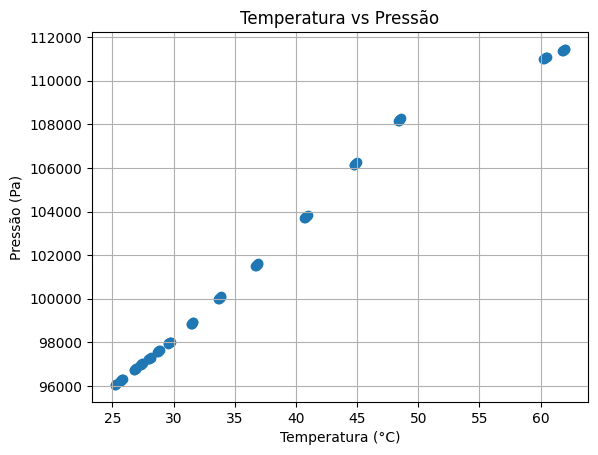

In [6]:
plt.scatter(df["Temperatura (°C)"], df["Pressão (Pa)"])
plt.xlabel("Temperatura (°C)")
plt.ylabel("Pressão (Pa)")
plt.title("Temperatura vs Pressão")
plt.grid()
plt.show()

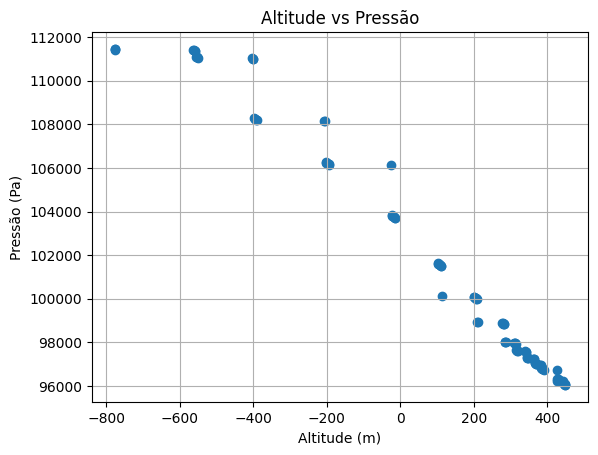

In [7]:
plt.scatter(df["Altitude (m)"], df["Pressão (Pa)"])
plt.xlabel("Altitude (m)")
plt.ylabel("Pressão (Pa)")
plt.title("Altitude vs Pressão")
plt.grid()
plt.show()

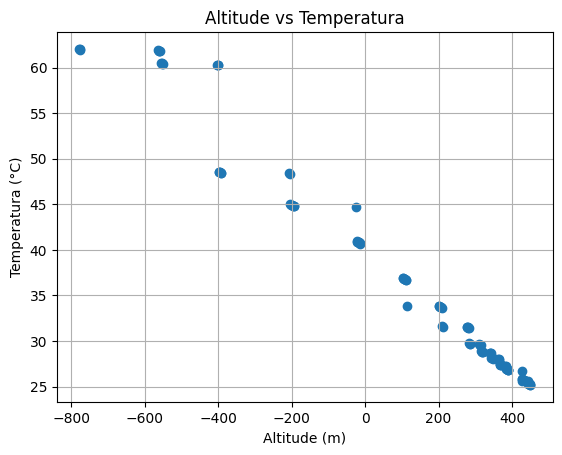

In [8]:
plt.scatter(df["Altitude (m)"], df["Temperatura (°C)"])
plt.xlabel("Altitude (m)")
plt.ylabel("Temperatura (°C)")
plt.title("Altitude vs Temperatura")
plt.grid()
plt.show()

In [9]:
correlacao = df.corr()

print(correlacao)

                  Altitude (m)  Temperatura (°C)  Pressão (Pa)
Altitude (m)          1.000000         -0.985591     -0.987319
Temperatura (°C)     -0.985591          1.000000      0.991671
Pressão (Pa)         -0.987319          0.991671      1.000000


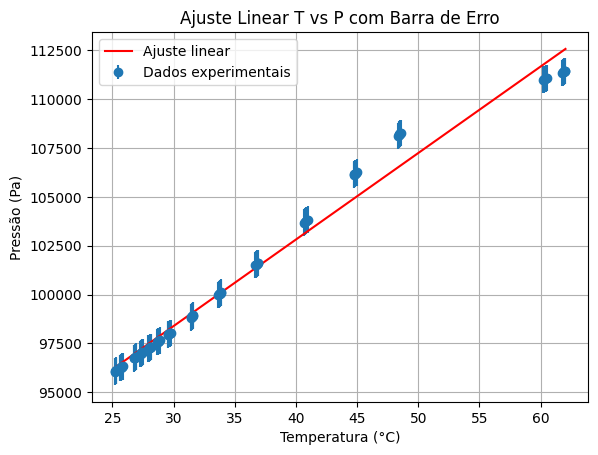

Equação: P = 443.04 * T + 85093.72


In [10]:



# garantir que df existe antes
x = df["Temperatura (°C)"]
y = df["Pressão (Pa)"]

# ajuste
coef = np.polyfit(x, y, 1)
reta = np.poly1d(coef)

# erro padrão
erro_y = np.full(len(y), 676.98)

# ordenar
idx = np.argsort(x)

# plot
plt.errorbar(x.iloc[idx], y.iloc[idx], yerr=erro_y[idx],
             fmt='o', label="Dados experimentais")

plt.plot(x.iloc[idx], reta(x.iloc[idx]),
         color="red", label="Ajuste linear")

plt.xlabel("Temperatura (°C)")
plt.ylabel("Pressão (Pa)")
plt.title("Ajuste Linear T vs P com Barra de Erro")
plt.legend()
plt.grid()

plt.show()

print(f"Equação: P = {coef[0]:.2f} * T + {coef[1]:.2f}")

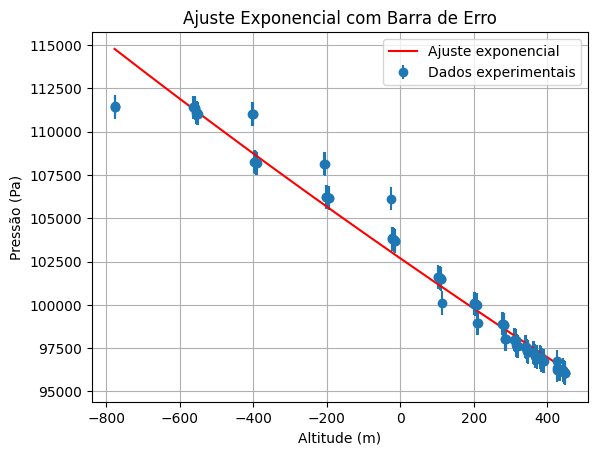

P0 = 102690.00635243193
k = 0.00014320840889009935


In [11]:


def modelo_exp(h, P0, k):
    return P0 * np.exp(np.clip(-k * h, -700, 700))

h = df["Altitude (m)"].values
P = df["Pressão (Pa)"].values

# erro padrão (mesmo usado antes)
erro_P = np.full(len(P), 676.98)

# chute inicial
p0 = (max(P), 1e-4)

params, _ = curve_fit(
    modelo_exp,
    h,
    P,
    p0=p0,
    bounds=(0, [np.inf, np.inf])
)

# ordenar para plot bonito
idx = np.argsort(h)

# plot com barras de erro
plt.errorbar(h[idx], P[idx], yerr=erro_P[idx],
             fmt='o', label="Dados experimentais")

# curva ajustada
h_linha = np.linspace(min(h), max(h), 200)
plt.plot(h_linha, modelo_exp(h_linha, *params),
         color='red', label="Ajuste exponencial")

plt.xlabel("Altitude (m)")
plt.ylabel("Pressão (Pa)")
plt.title("Ajuste Exponencial com Barra de Erro")
plt.legend()
plt.grid()

plt.show()

print("P0 =", params[0])
print("k =", params[1])


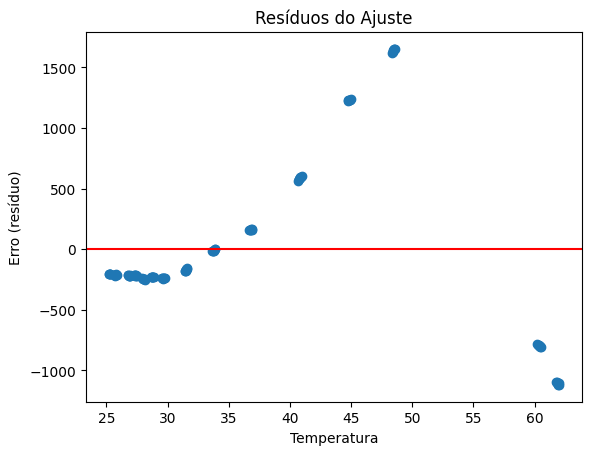

In [12]:
residuos = y - reta(x)

plt.scatter(x, residuos)
plt.axhline(0, color='red')
plt.xlabel("Temperatura")
plt.ylabel("Erro (resíduo)")
plt.title("Resíduos do Ajuste")
plt.show()

In [13]:
erro_std = np.std(residuos)
print("Erro padrão:", erro_std)

Erro padrão: 676.980442077177


In [14]:
erro_relativo = np.mean(abs(residuos / y)) * 100
print("Erro relativo (%):", erro_relativo)

Erro relativo (%): 0.46258854723179677


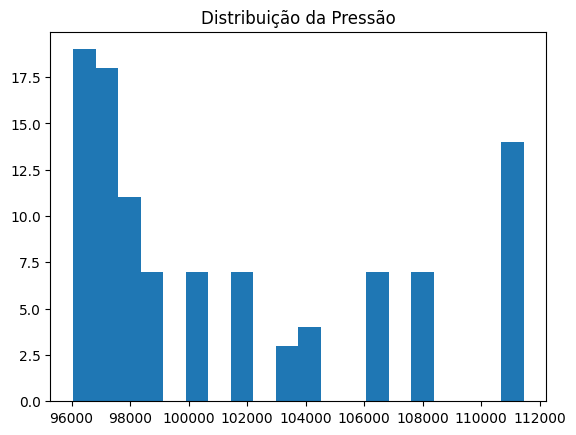

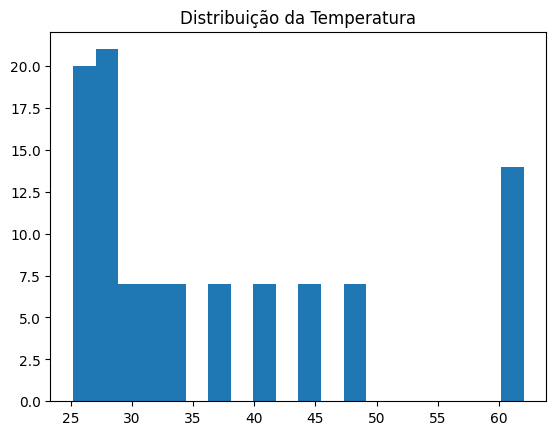

In [15]:
plt.hist(df["Pressão (Pa)"], bins=20)
plt.title("Distribuição da Pressão")
plt.show()

plt.hist(df["Temperatura (°C)"], bins=20)
plt.title("Distribuição da Temperatura")
plt.show()

In [16]:
X = df[["Temperatura (°C)", "Altitude (m)"]]
y = df["Pressão (Pa)"]

modelo = LinearRegression()
modelo.fit(X, y)

print("Coeficientes:", modelo.coef_)
print("Intercepto:", modelo.intercept_)

Coeficientes: [290.10284046  -5.26097035]
Intercepto: 91233.04151444064


In [17]:
df.to_csv("dados_tratados.csv", index=False)